In [1]:
import random, os, re, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import classification_report, f1_score, accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

PREPROCESSED_DIR = "/kaggle/input/datasets/iftekharuddin27/preprocessed-datasets"
MODELS_DIR       = "/kaggle/input/datasets/iftekharuddin27/transformer-learning"
EXTERNAL_DIR     = "/kaggle/input/datasets/faisalshanto/external-hate-dataset"
OUTPUT_DIR       = "/kaggle/working/"
MODEL_NAME       = "xlm-roberta-base"
MAX_LEN          = 128
device           = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES      = {0: 'Non-hateful', 1: 'Hateful', 2: 'Sarcastic'}
print(f"Device: {device}")

Device: cuda


In [2]:
def load_olid(path):
    df = pd.read_csv(path, sep='\t')
    print(f"OLID shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print(f"subtask_a distribution: {df['subtask_a'].value_counts().to_dict()}")

    # OFF=Offensive→Hateful(1), NOT=Not offensive→Non-hateful(0)
    df['class'] = df['subtask_a'].map({'OFF': 1, 'NOT': 0})
    df = df.dropna(subset=['class'])
    df['class'] = df['class'].astype(int)
    df['text_clean'] = df['tweet'].fillna('').apply(
        lambda t: re.sub(r'http\S+|@\w+|#\w+', '', str(t)).strip().lower())
    df['is_hateful']   = df['class']
    df['is_sarcastic'] = 0
    return df[['text_clean','class','is_hateful','is_sarcastic']], "OLID", 2019

import os
files = os.listdir(EXTERNAL_DIR)
print(f"Files in external dataset: {files}")

if any('olid' in f.lower() or '.tsv' in f for f in files):
    tsv_file = [f for f in files if '.tsv' in f][0]
    ext_df, EXT_NAME, EXT_YEAR = load_olid(f"{EXTERNAL_DIR}/{tsv_file}")
    
else:
    raise FileNotFoundError(
        f"Could not find OLID (.tsv) or HatEval (.csv) in {EXTERNAL_DIR}. "
        f"Files found: {files}")

print(f"\nLoaded: {EXT_NAME} ({EXT_YEAR})")
print(f"Total texts  : {len(ext_df):,}")
print(f"Class dist   : {ext_df['class'].value_counts().to_dict()}")
print(f"Note: No sarcastic class in external dataset (expected)")

Files in external dataset: ['olid-training-v1.0.tsv']
OLID shape: (13240, 5)
Columns: ['id', 'tweet', 'subtask_a', 'subtask_b', 'subtask_c']
subtask_a distribution: {'NOT': 8840, 'OFF': 4400}

Loaded: OLID (2019)
Total texts  : 13,240
Class dist   : {0: 8840, 1: 4400}
Note: No sarcastic class in external dataset (expected)


In [3]:
class SharedDualHeadModel(nn.Module):
    def __init__(self, model_name, num_classes=3, dropout=0.3):
        super().__init__()
        self.encoder  = AutoModel.from_pretrained(model_name)
        hidden_size   = self.encoder.config.hidden_size
        self.dropout  = nn.Dropout(dropout)
        self.hate_head = nn.Sequential(
            nn.Linear(hidden_size, 256), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(256, 1))
        self.sarcasm_head = nn.Sequential(
            nn.Linear(hidden_size, 256), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(256, 1))
        self.fusion_mlp = nn.Sequential(
            nn.Linear(hidden_size+256+256, 512), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(512,128), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(128, num_classes))

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        out   = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls   = self.dropout(out.last_hidden_state[:, 0, :])
        hh    = self.dropout(F.relu(self.hate_head[0](cls)))
        sh    = self.dropout(F.relu(self.sarcasm_head[0](cls)))
        fused = torch.cat([cls, hh, sh], dim=1)
        return self.fusion_mlp(fused), self.hate_head[3](hh).squeeze(-1), \
               self.sarcasm_head[3](sh).squeeze(-1)


class SimpleDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(list(texts), truncation=True,
                                   padding=True, max_length=max_len,
                                   return_tensors='pt')
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

In [4]:
print("Loading English-trained dual-head model...")
tokenizer = AutoTokenizer.from_pretrained(
    f"{MODELS_DIR}/dualhead_xlmr_English")
model     = SharedDualHeadModel(MODEL_NAME).to(device)
model.load_state_dict(torch.load(
    f"{MODELS_DIR}/dualhead_xlmr_English/model.pt", 
    map_location=device, 
    weights_only=False))
model.eval()

ext_ds     = SimpleDataset(ext_df['text_clean'].values,
                            ext_df['class'].values, tokenizer, MAX_LEN)
ext_loader = DataLoader(ext_ds, batch_size=64, shuffle=False)

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for batch in ext_loader:
        ids    = batch['input_ids'].to(device)
        mask   = batch['attention_mask'].to(device)
        logits, _, _ = model(ids, mask)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(batch['labels'].numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# External dataset has only classes 0 and 1 (no sarcasm)
unique_cls = np.unique(all_labels)
present    = [CLASS_NAMES[c] for c in unique_cls]

acc_ext = accuracy_score(all_labels, all_preds)
f1_ext  = f1_score(all_labels, all_preds, average='macro',
                   labels=unique_cls, zero_division=0)

print(f"\n{'='*60}")
print(f"Zero-Shot: {EXT_NAME} ({EXT_YEAR})")
print(f"{'='*60}")
print(f"Accuracy : {acc_ext:.4f}")
print(f"Macro F1 : {f1_ext:.4f}  (classes present: {present})")
print(classification_report(all_labels, all_preds,
                            labels=unique_cls,
                            target_names=present,
                            zero_division=0))

np.save(f"{OUTPUT_DIR}preds_6E_external.npy", all_preds)
np.save(f"{OUTPUT_DIR}probs_6E_external.npy", all_probs)

# Drift measurement
own_f1  = 0.9029   # BERT on own EN test set
drop    = own_f1 - f1_ext
pct_drop = drop / own_f1 * 100
print(f"\nOwn EN test F1 (BERT baseline) : {own_f1:.4f}")
print(f"Zero-shot {EXT_NAME} F1        : {f1_ext:.4f}")
print(f"Absolute drop                  : {drop:.4f}")
print(f"Relative degradation           : {pct_drop:.1f}%")

Loading English-trained dual-head model...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Zero-Shot: OLID (2019)
Accuracy : 0.5161
Macro F1 : 0.5814  (classes present: ['Non-hateful', 'Hateful'])
              precision    recall  f1-score   support

 Non-hateful       0.79      0.50      0.62      8840
     Hateful       0.55      0.54      0.55      4400

   micro avg       0.69      0.52      0.59     13240
   macro avg       0.67      0.52      0.58     13240
weighted avg       0.71      0.52      0.59     13240


Own EN test F1 (BERT baseline) : 0.9029
Zero-shot OLID F1        : 0.5814
Absolute drop                  : 0.3215
Relative degradation           : 35.6%



Avg confidence (own test set) : 0.9329
Avg confidence (OLID)  : 0.9182


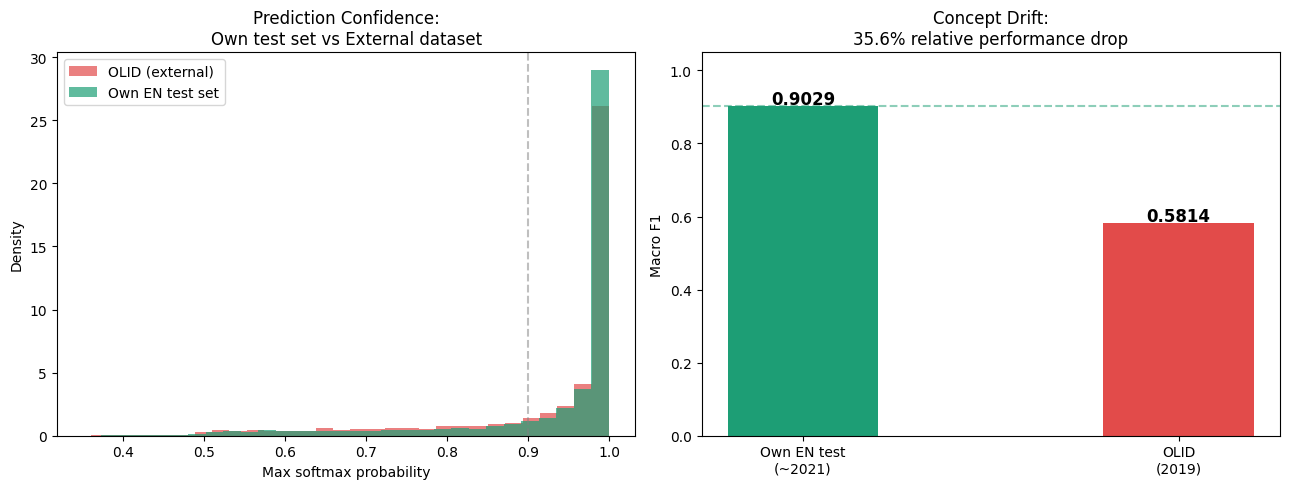

Saved: phase6e_concept_drift.png


In [5]:
own_probs_path = "/kaggle/input/datasets/faisalshanto/bert-english-probs/val_probs_BERT_English.npy"

fig, axes = plt.subplots(1, 2, figsize=(13, 5))


ax = axes[0]
ext_max_conf = all_probs.max(axis=1)
ax.hist(ext_max_conf, bins=30, alpha=0.7,
        color='#E24B4A', label=f'{EXT_NAME} (external)', density=True)

if os.path.exists(own_probs_path):
    own_probs    = np.load(own_probs_path)
    own_max_conf = own_probs.max(axis=1)
    ax.hist(own_max_conf, bins=30, alpha=0.7,
            color='#1D9E75', label='Own EN test set', density=True)
    print(f"\nAvg confidence (own test set) : {own_max_conf.mean():.4f}")

print(f"Avg confidence ({EXT_NAME})  : {ext_max_conf.mean():.4f}")
ax.set_xlabel('Max softmax probability')
ax.set_ylabel('Density')
ax.set_title('Prediction Confidence:\nOwn test set vs External dataset')
ax.legend()
ax.axvline(x=0.9, color='gray', linestyle='--', alpha=0.5, label='0.9')

ax2 = axes[1]
dataset_names  = [f'Own EN test\n(~2021)', f'{EXT_NAME}\n({EXT_YEAR})']
dataset_f1s    = [own_f1, f1_ext]
bar_colors     = ['#1D9E75', '#E24B4A']
bars = ax2.bar(dataset_names, dataset_f1s, color=bar_colors, width=0.4)
for bar, val in zip(bars, dataset_f1s):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
ax2.set_ylabel('Macro F1')
ax2.set_title(f'Concept Drift:\n{pct_drop:.1f}% relative performance drop')
ax2.set_ylim(0, 1.05)
ax2.axhline(y=own_f1, color='#1D9E75', linestyle='--',
            alpha=0.5, label='Own test baseline')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}phase6e_concept_drift.png", dpi=150)
plt.show()
print("Saved: phase6e_concept_drift.png")

In [7]:
drift_summary = pd.DataFrame([
    {'Dataset': 'Own EN test set', 'Year': '~2021',
     'Source': 'Training distribution',
     'Macro F1': own_f1, 'Type': 'In-distribution'},
    {'Dataset': EXT_NAME, 'Year': EXT_YEAR,
     'Source': 'External (unseen)',
     'Macro F1': round(f1_ext, 4), 'Type': 'Zero-shot'},
])

print("\n" + "="*65)
print("PHASE 6E — CONCEPT DRIFT SUMMARY")
print("="*65)
print(drift_summary.to_string(index=False))
drift_summary.to_csv(f"{OUTPUT_DIR}phase6e_concept_drift.csv", index=False)

print(f"""
Key findings:
  Model trained on own corpus: F1 = {own_f1:.4f}
  Model zero-shot on {EXT_NAME}: F1 = {f1_ext:.4f}
  Performance drop: {drop:.4f} ({pct_drop:.1f}% relative degradation)
""")


PHASE 6E — CONCEPT DRIFT SUMMARY
        Dataset  Year                Source  Macro F1            Type
Own EN test set ~2021 Training distribution    0.9029 In-distribution
           OLID  2019     External (unseen)    0.5814       Zero-shot

Key findings:
  Model trained on own corpus: F1 = 0.9029
  Model zero-shot on OLID: F1 = 0.5814
  Performance drop: 0.3215 (35.6% relative degradation)

